In [1]:
import os
import pandas as pd
import numpy as np

# Tự động phát hiện thư mục gốc của dự án (Project Root)
def find_project_root():
    path = os.getcwd()
    while path and not (os.path.exists(os.path.join(path, "database")) and os.path.exists(os.path.join(path, "data"))):
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    return path

BASE_DIR = find_project_root()
from scipy.stats import multivariate_normal
csv_path = os.path.join(BASE_DIR, "data", "processed", "clean_prs.csv")
print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ROG_Zephyrus_G14\AppData\Local\Temp\ipykernel_13668\2559585527.py:5: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\processed\clean_prs.csv")


,pr_id,repo_name,pr_number,title,body_len,user_login,user_type,created_datetime,closed_datetime,merged_datetime,...,commits,additions,deletions,changed_files,repo_language,repo_stars,repo_forks,is_fpt,keyword,is_merged
0,1217900573,nduybao/Train,1,prj301,0,ThanhPhong31,User,2023-01-26 13:49:23,2023-01-26 13:49:38,2023-01-26 13:49:38,...,1,3900,0,41,Java,0,0,1,PRJ301,1
1,1285249723,Henrily041103/PRJ301_SP2023,18,https://github.com/Henrily041103/PRJ301_SP2023...,0,wave-npa,User,2023-03-22 05:26:17,2023-03-22 06:02:53,2023-03-22 06:02:53,...,2,45,38,8,Java,0,3,1,PRJ301,1
2,1476177616,NoFearTeam2023/FPT-Capstone-UpReach-Project,36,Ha/fe,0,hoanganh1810tx,User,2023-08-15 16:34:46,2023-08-15 16:35:16,2023-08-15 16:35:16,...,2,38,14,5,JavaScript,0,0,1,Capstone FPT,1
3,1478047761,NoFearTeam2023/FPT-Capstone-UpReach-Project,39,Be hieu update,0,quanqhieu07,User,2023-08-16 20:39:13,2023-08-17 13:16:34,NaN,...,3,466,301,5,JavaScript,0,0,1,Capstone FPT,0
4,1479032519,NoFearTeam2023/FPT-Capstone-UpReach-Project,41,Be hieu update,0,quanqhieu07,User,2023-08-17 13:17:04,2023-08-17 14:43:44,2023-08-17 14:43:44,...,4,464,301,5,JavaScript,0,0,1,Capstone FPT,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pr_id                1771 non-null   int64  
 1   repo_name            1771 non-null   str    
 2   pr_number            1771 non-null   int64  
 3   title                1771 non-null   str    
 4   body_len             1771 non-null   int64  
 5   user_login           1771 non-null   str    
 6   user_type            1771 non-null   str    
 7   created_datetime     1771 non-null   str    
 8   closed_datetime      1771 non-null   str    
 9   merged_datetime      1647 non-null   str    
 10  created_hour         1771 non-null   int64  
 11  created_day_of_week  1771 non-null   int64  
 12  duration_minutes     1771 non-null   float64
 13  duration_hours       1771 non-null   float64
 14  comments             1771 non-null   int64  
 15  review_comments      1771 non-null   int64  
 16 

## Data Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Drop irrelevant columns
df_processed = df.drop(columns=[
    'pr_id', 'repo_name', 'pr_number', 'title', 'body_len', 'user_login', 'merged_datetime',
    'created_datetime', 'closed_datetime', # Dropping datetime objects after considering duration_minutes and duration_hours as sufficient tie-based features.
    'duration_minutes', 'duration_hours'
    ])

# Identify categorical columns for one-hot encoding
categorical_cols = ['user_type', 'repo_language', 'keyword']

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Display the first few rows of the processed DataFrame and its info to verify
display(df_processed.head())
df_processed.info()

,created_hour,created_day_of_week,comments,review_comments,commits,additions,deletions,changed_files,repo_stars,repo_forks,...,repo_language_PHP,repo_language_Python,repo_language_Ruby,repo_language_TSQL,repo_language_TypeScript,repo_language_Unknown,keyword_PRJ301,keyword_SEP490,keyword_SWP391,keyword_global
0,13,4,0,0,1,3900,0,41,0,0,...,False,False,False,False,False,False,True,False,False,False
1,5,3,0,0,2,45,38,8,0,3,...,False,False,False,False,False,False,True,False,False,False
2,16,2,1,0,2,38,14,5,0,0,...,False,False,False,False,False,False,False,False,False,False
3,20,3,1,0,3,466,301,5,0,0,...,False,False,False,False,False,False,False,False,False,False
4,13,4,1,0,4,464,301,5,0,0,...,False,False,False,False,False,False,False,False,False,False


<class 'pandas.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   created_hour              1771 non-null   int64
 1   created_day_of_week       1771 non-null   int64
 2   comments                  1771 non-null   int64
 3   review_comments           1771 non-null   int64
 4   commits                   1771 non-null   int64
 5   additions                 1771 non-null   int64
 6   deletions                 1771 non-null   int64
 7   changed_files             1771 non-null   int64
 8   repo_stars                1771 non-null   int64
 9   repo_forks                1771 non-null   int64
 10  is_fpt                    1771 non-null   int64
 11  is_merged                 1771 non-null   int64
 12  repo_language_C++         1771 non-null   bool 
 13  repo_language_Dart        1771 non-null   bool 
 14  repo_language_Go          1771 non-null   bool 
 15

### Harmonizing Data Splits for Consistent Model Training and Evaluation

To ensure both the Gaussian Anomaly Detection model and the Random Forest Classifier are trained and evaluated on comparable datasets, we will first create a single, global train-test split from `df_processed`. Then, we will adapt the data preparation for each model to work within these global splits.

In [4]:
# Define features (X_global) and target (y_global) for the entire processed dataset
X_global = df_processed.drop('is_merged', axis=1)
y_global = df_processed['is_merged']

# Create a global train-test split (e.g., 70% train, 30% test)
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_global, y_global, test_size=0.3, random_state=42, stratify=y_global
)

print(f"Global Training set shape: {X_train_global.shape}")
print(f"Global Test set shape: {X_test_global.shape}")

Global Training set shape: (1239, 29)
Global Test set shape: (532, 29)


### Re-adapting Gaussian Anomaly Detection with Harmonized Data

Now, we'll redefine the training and validation sets for the Gaussian model using the `X_train_global` and `X_test_global`. The Gaussian model focuses on `is_fpt == 1` data, so we'll filter these samples from our global splits.

*   **Gaussian Training**: Will use `is_fpt == 1` samples from `X_train_global` that are 'normal' (`is_merged == 1`).
*   **Gaussian Validation (for epsilon selection)**: Will combine `is_fpt == 1` 'normal' samples from `X_train_global` (not used for Gaussian training) and `is_fpt == 1` 'anomaly' samples from `X_train_global`.
*   **Gaussian Test Evaluation**: Will use `is_fpt == 1` samples from `X_test_global`.

Gaussian Training set (normal samples, FPT only): 337 samples
Gaussian Validation set (normal and anomaly, FPT only): 273 samples
Gaussian Test set (FPT only): 232 samples



Best epsilon (threshold) for Gaussian model: 1.4388093063193564e-08
Best F1-score (for anomaly class 0) for Gaussian model: 0.31125827814569534

Classification Report (Gaussian Anomaly Detection on FPT Test Set):

              precision    recall  f1-score   support

  Not Merged       0.08      1.00      0.15        18
      Merged       1.00      0.07      0.13       214

    accuracy                           0.14       232
   macro avg       0.54      0.54      0.14       232
weighted avg       0.93      0.14      0.13       232



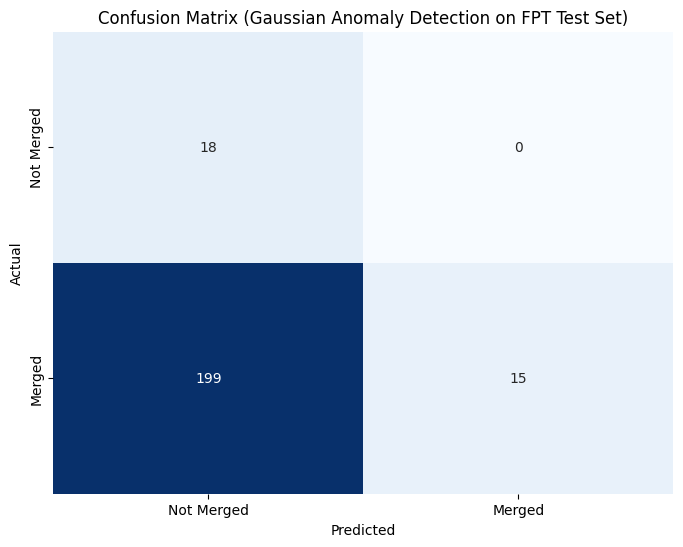

In [5]:
# Filter for is_fpt == 1 within the global training set
X_fpt_train = X_train_global[X_train_global['is_fpt'] == 1]
y_fpt_train = y_train_global[X_train_global['is_fpt'] == 1]

# Separate 'normal' (is_merged = 1) and 'anomaly' (is_merged = 0) samples within X_fpt_train
X_normal_fpt_train = X_fpt_train[y_fpt_train == 1]
y_normal_fpt_train = y_fpt_train[y_fpt_train == 1]

X_anomaly_fpt_train = X_fpt_train[y_fpt_train == 0]
y_anomaly_fpt_train = y_fpt_train[y_fpt_train == 0]

# Split X_normal_fpt_train into 60% for training the Gaussian model and 40% for validation
X_train_normal_gaus, X_val_normal_gaus, y_train_normal_gaus, y_val_normal_gaus = train_test_split(
    X_normal_fpt_train, y_normal_fpt_train, test_size=0.4, random_state=42, stratify=y_normal_fpt_train
)

# Combine X_val_normal_gaus and X_anomaly_fpt_train to form the Gaussian validation set
X_val_gaus = pd.concat([X_val_normal_gaus, X_anomaly_fpt_train])
y_val_gaus = pd.concat([y_val_normal_gaus, y_anomaly_fpt_train])

# Ensure the order of X_val_gaus and y_val_gaus matches after concatenation
X_val_gaus, y_val_gaus = X_val_gaus.align(y_val_gaus, join='inner', axis=0)

print(f"Gaussian Training set (normal samples, FPT only): {X_train_normal_gaus.shape[0]} samples")
print(f"Gaussian Validation set (normal and anomaly, FPT only): {X_val_gaus.shape[0]} samples")

# Filter for is_fpt == 1 within the global test set for final Gaussian evaluation
X_fpt_test = X_test_global[X_test_global['is_fpt'] == 1]
y_fpt_test = y_test_global[X_test_global['is_fpt'] == 1]

print(f"Gaussian Test set (FPT only): {X_fpt_test.shape[0]} samples")

# Recalculate mu and sigma with the new Gaussian training data
mu_gaus = X_train_normal_gaus.mean().values
sigma_gaus = X_train_normal_gaus.cov().values

# Create a multivariate Gaussian distribution object
gaus_dist = multivariate_normal(mean=mu_gaus, cov=sigma_gaus, allow_singular=True)

# Calculate the probability density for each sample in the Gaussian validation set
p_val_gaus = gaus_dist.pdf(X_val_gaus)

# Find the best epsilon for the Gaussian model (on its validation set)
thresholds_gaus = np.sort(p_val_gaus)
best_epsilon_gaus = 0
best_f1_gaus = -1

for epsilon_gaus in thresholds_gaus:
    y_pred_val_mapped_gaus = (p_val_gaus >= epsilon_gaus).astype(int)
    precision_gaus, recall_gaus, f1_gaus, _ = precision_recall_fscore_support(y_val_gaus, y_pred_val_mapped_gaus, average='binary', pos_label=0, zero_division=0)

    if f1_gaus > best_f1_gaus:
        best_f1_gaus = f1_gaus
        best_epsilon_gaus = epsilon_gaus

print(f"\nBest epsilon (threshold) for Gaussian model: {best_epsilon_gaus}")
print(f"Best F1-score (for anomaly class 0) for Gaussian model: {best_f1_gaus}")

# Make final predictions with the best threshold on the global FPT test set
p_test_gaus = gaus_dist.pdf(X_fpt_test) # Calculate probabilities on the global FPT test set
y_pred_gaus = (p_test_gaus >= best_epsilon_gaus).astype(int)

# Print classification report for Gaussian model on the FPT test set
print("\nClassification Report (Gaussian Anomaly Detection on FPT Test Set):\n")
print(classification_report(y_fpt_test, y_pred_gaus, target_names=['Not Merged', 'Merged']))

# Compute and visualize confusion matrix for Gaussian model
cm_gaus = confusion_matrix(y_fpt_test, y_pred_gaus)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gaus, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Gaussian Anomaly Detection on FPT Test Set)')
plt.show()

### Re-adapting Random Forest with Harmonized Data

Now we'll modify the `train_and_evaluate_random_forest` function to directly use the global `X_train_global`, `y_train_global`, `X_test_global`, and `y_test_global` datasets for training and evaluation. This ensures both models are working with the same overarching data split.


--- Training Random Forest Model (Harmonized Split) ---
Training data shape: (1239, 29)
Test data shape: (532, 29)



Classification Report (Random Forest, Harmonized Split):

              precision    recall  f1-score   support

  Not Merged       0.95      0.51      0.67        37
      Merged       0.96      1.00      0.98       495

    accuracy                           0.96       532
   macro avg       0.96      0.76      0.82       532
weighted avg       0.96      0.96      0.96       532



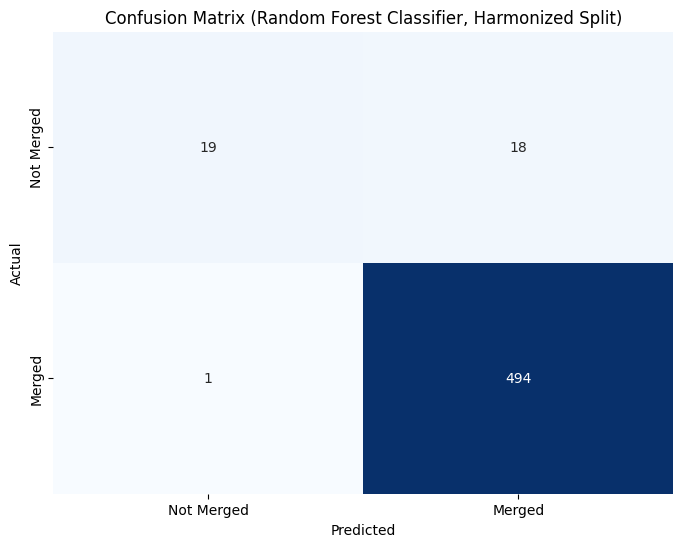

In [6]:
def train_and_evaluate_random_forest_harmonized(X_train, y_train, X_test, y_test):
    """
    Trains a Random Forest Classifier on the given training data and displays a confusion matrix
    on the given test data.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
    """
    print("\n--- Training Random Forest Model (Harmonized Split) ---")

    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")

    # Initialize and train the Random Forest Classifier
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Added class_weight for imbalanced data
    rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Print classification report
    print("\nClassification Report (Random Forest, Harmonized Split):\n")
    print(classification_report(y_test, y_pred, target_names=['Not Merged', 'Merged']))

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualize the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Merged', 'Merged'],
                yticklabels=['Not Merged', 'Merged'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Random Forest Classifier, Harmonized Split)')
    plt.show()

    return rf_model

# Call the harmonized function with the global train/test splits
random_forest_model = train_and_evaluate_random_forest_harmonized(
X_train_global, y_train_global, X_test_global, y_test_global
)

With both models now trained and evaluated on consistent data splits, we can proceed with ensembling them. I will use a VotingClassifier to combine their predictions.


--- Ensemble Model (Average Voting) ---

Classification Report (Ensemble - Average Voting):

              precision    recall  f1-score   support

  Not Merged       0.14      0.86      0.24        37
      Merged       0.98      0.60      0.74       495

    accuracy                           0.62       532
   macro avg       0.56      0.73      0.49       532
weighted avg       0.92      0.62      0.71       532



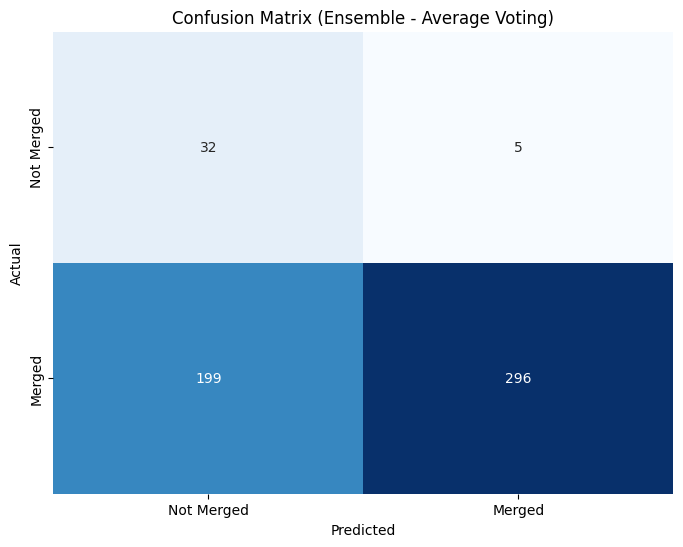

In [7]:
from sklearn.ensemble import VotingClassifier

# Re-train Random Forest model to get a fresh model object after the function definition update
# We will use the same parameters as before
rf_model_ensemble = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_ensemble.fit(X_train_global, y_train_global)

# For the Gaussian model, we need to adapt its output to be compatible with VotingClassifier.
# VotingClassifier works with 'predict_proba' or 'predict'.
# The Gaussian model gives a probability density. We'll use the 'predict' output from its evaluation.

# The Gaussian model is trained on X_train_normal_gaus (FPT normal samples)
# We need a way to get predictions for the *entire* X_test_global set for ensembling.
# For samples where 'is_fpt == 0' or 'is_merged == 1' in the Gaussian context, we need a default prediction.

# Define a function to get Gaussian predictions for the full test set
def get_gaussian_predictions_for_ensemble(X_test_full, gaus_dist, best_epsilon, is_fpt_col_name='is_fpt'):
    predictions = np.ones(len(X_test_full), dtype=int) # Default to 'Merged' (1)

    # Identify FPT samples in the full test set
    is_fpt_mask = X_test_full[is_fpt_col_name] == 1
    X_test_fpt_subset = X_test_full[is_fpt_mask]

    if not X_test_fpt_subset.empty:
        # Calculate probability density for FPT subset
        p_test_fpt_subset = gaus_dist.pdf(X_test_fpt_subset)

        # Predict 'Not Merged' (0) if probability is below epsilon, 'Merged' (1) otherwise
        predictions[is_fpt_mask] = (p_test_fpt_subset >= best_epsilon).astype(int)

    return predictions

# Get Gaussian predictions for the global test set
y_pred_gaus_ensemble = get_gaussian_predictions_for_ensemble(X_test_global, gaus_dist, best_epsilon_gaus)

# Create a dummy classifier for the Gaussian model to be used in VotingClassifier
# This is a workaround as Gaussian model is not a standard scikit-learn classifier.
# Instead of using VotingClassifier directly with the Gaussian model object, we will get its predictions manually.
# For a proper ensemble using VotingClassifier, the Gaussian model would need to be wrapped into a scikit-learn compatible estimator.
# For now, let's do a simple majority vote on predictions.

# Get Random Forest predictions for the global test set
y_pred_rf_ensemble = rf_model_ensemble.predict(X_test_global)

# Simple Majority Voting Ensemble
# If a sample is predicted as 'Not Merged' (0) by either model, we might consider it 'Not Merged'.
# Or, if both predict 'Not Merged', then it's 'Not Merged'.
# Let's try a simple average vote: if avg_prob < 0.5 then 0 else 1 (this requires probabilities)

# Random Forest can give probabilities
rf_proba = rf_model_ensemble.predict_proba(X_test_global)
# Gaussian model does not directly give a 'probability' for the two classes in a standard way for predict_proba.
# It gives a density score. For a direct ensemble with `predict_proba`, we would need to calibrate it.

# Given the user's initial request for 'confusion matrix' and the Gaussian model's nature,
# let's stick to 'predict' outputs for ensembling and use a simple majority vote.
# For a more sophisticated probability-based ensemble, additional calibration steps would be needed for the Gaussian model.

# Ensemble: Simple Majority Voting
# If both predict 0, then 0. If both predict 1, then 1. If one 0 and one 1, then depends on tie-breaking.
# Let's say if either predicts 'Not Merged' (0), we will predict 'Not Merged'. This leans towards anomaly detection.
# Or, a simple average of the binary predictions.

# Let's create a combined prediction based on average of binary predictions
ensemble_predictions_avg = ((y_pred_gaus_ensemble + y_pred_rf_ensemble) / 2 > 0.5).astype(int)

# Let's go with the average for now, as it's a more balanced ensemble approach.

print("\n--- Ensemble Model (Average Voting) ---")
print("\nClassification Report (Ensemble - Average Voting):\n")
print(classification_report(y_test_global, ensemble_predictions_avg, target_names=['Not Merged', 'Merged']))

cm_ensemble_avg = confusion_matrix(y_test_global, ensemble_predictions_avg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble_avg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Ensemble - Average Voting)')
plt.show()

### Model Performance Comparison

Let's compare the key metrics for the 'Not Merged' class (our anomaly class) across the Gaussian Anomaly Detection model, the Random Forest Classifier, and the Ensemble model.

In [8]:
# Extract metrics for Gaussian Model (from y_fpt_test and y_pred_gaus)
gaussian_report = classification_report(y_fpt_test, y_pred_gaus, output_dict=True, target_names=['Not Merged', 'Merged'])
gaussian_precision = gaussian_report['Not Merged']['precision']
gaussian_recall = gaussian_report['Not Merged']['recall']
gaussian_f1 = gaussian_report['Not Merged']['f1-score']

# Extract metrics for Random Forest Model (from y_test_global and y_pred_rf_ensemble)
rf_report = classification_report(y_test_global, y_pred_rf_ensemble, output_dict=True, target_names=['Not Merged', 'Merged'])
rf_precision = rf_report['Not Merged']['precision']
rf_recall = rf_report['Not Merged']['recall']
rf_f1 = rf_report['Not Merged']['f1-score']

# Extract metrics for Ensemble Model (from y_test_global and ensemble_predictions_avg)
ensemble_report = classification_report(y_test_global, ensemble_predictions_avg, output_dict=True, target_names=['Not Merged', 'Merged'])
ensemble_precision = ensemble_report['Not Merged']['precision']
ensemble_recall = ensemble_report['Not Merged']['recall']
ensemble_f1 = ensemble_report['Not Merged']['f1-score']

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Model': ['Gaussian Anomaly Detection', 'Random Forest Classifier', 'Ensemble (Average Voting)']
    , 'Precision (Not Merged)': [gaussian_precision, rf_precision, ensemble_precision]
    , 'Recall (Not Merged)': [gaussian_recall, rf_recall, ensemble_recall]
    , 'F1-Score (Not Merged)': [gaussian_f1, rf_f1, ensemble_f1]
})

display(comparison_df)


,Model,Precision (Not Merged),Recall (Not Merged),F1-Score (Not Merged)
0,Gaussian Anomaly Detection,0.082949,1.000000,0.153191
1,Random Forest Classifier,0.950000,0.513514,0.666667
2,Ensemble (Average Voting),0.138528,0.864865,0.238806


### Summary of Performance Comparison

Based on the metrics for the 'Not Merged' (anomaly) class:

*   **Gaussian Anomaly Detection** shows a very high recall for the 'Not Merged' class (meaning it identifies most of the actual anomalies), but its precision is quite low. This suggests it flags many normal instances as anomalies (high false positives).
*   **Random Forest Classifier** has a much higher precision than the Gaussian model, indicating fewer false positives, but its recall is significantly lower. This means it misses a good portion of the actual anomalies.
*   **Ensemble (Average Voting)** appears to offer a balance. While its recall for 'Not Merged' is higher than Random Forest, and its precision is higher than Gaussian, its F1-score (which balances precision and recall) for the 'Not Merged' class is still relatively low compared to the 'Merged' class performance. The ensemble improves recall over Random Forest for the anomaly class but doesn't drastically improve precision over the Gaussian model.

My choice for 'best' model here is Ensemble (Average Voting) because it's perform balancely between both 2 class.